In [10]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import bptf
from bptf import BPTF
import numpy as np
import pandas as pd
import sparse
import os
import shutil
from tqdm import tqdm
import pickle
import gdelt
import scipy.stats as st
import matplotlib.pyplot as plt
import torch
import tensorly
import cupy

from datetime import datetime, timedelta

import multiprocessing
from joblib import Parallel, delayed
from tqdm.contrib.concurrent import process_map

import requests
from bs4 import BeautifulSoup

import copy

print(os.getcwd())

import gc
gc.collect()

<IPython.core.display.Javascript object>

Kernel is restarting...
c:\Users\luiyu\Documents\aaron_schein\bptf_new


30496

In [ ]:
gdelt_filepaths = [os.path.join('gdeltv1', f) for f in os.listdir('gdeltv1')]
gdelt1 = [pd.read_csv(gdelt_filepath) for gdelt_filepath in tqdm(gdelt_filepaths)]
gdelt1 = pd.concat(gdelt1)
print(f'data types: {gdelt1.dtypes}')

100%|██████████| 1020/1020 [00:12<00:00, 80.87it/s]


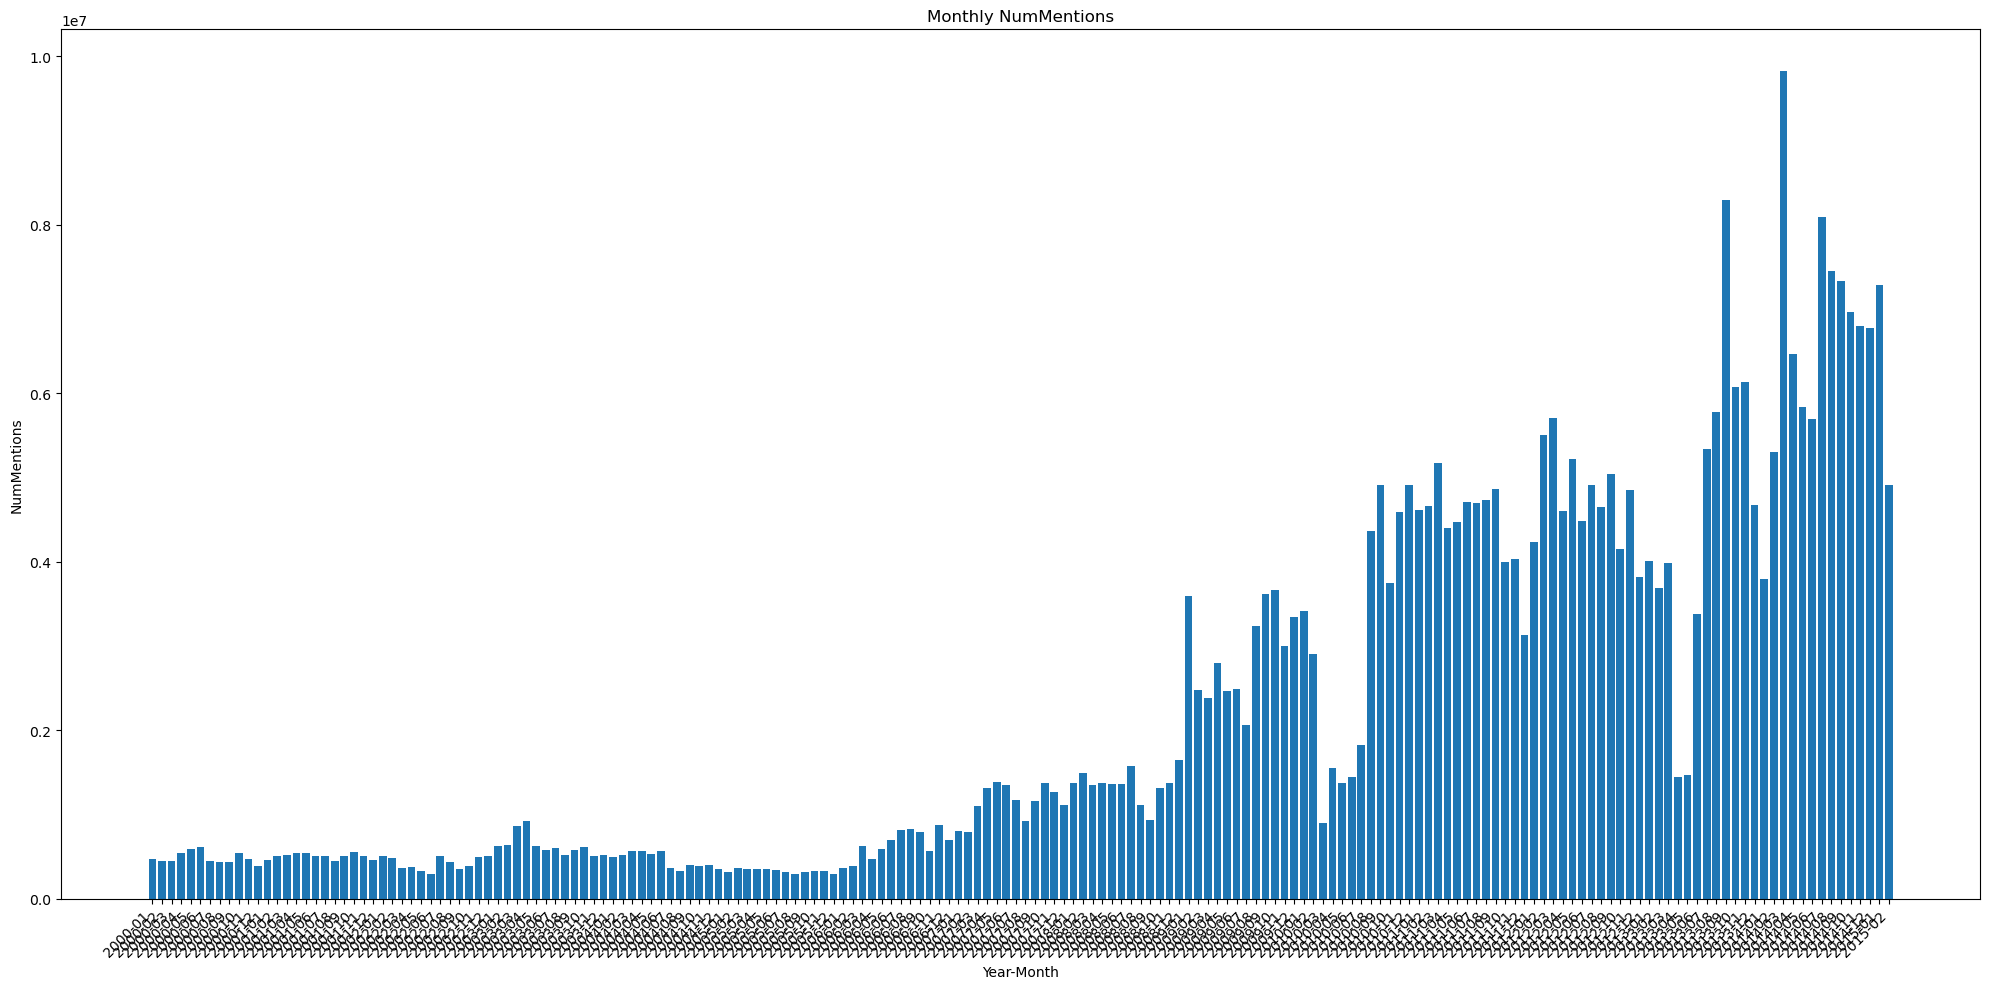

In [12]:
gdelt1['SQLDATE'] = pd.to_datetime(gdelt1['SQLDATE'], format='%Y%m%d', errors='coerce')
gdelt1['month_year'] = gdelt1['SQLDATE'].dt.to_period('M')
gdelt1 = gdelt1.groupby('month_year')['NumMentions'].sum()

plt.figure(figsize=(20, 10))
plt.bar(gdelt1.index.astype(str), gdelt1.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Year-Month')
plt.ylabel('NumMentions')
plt.title('Monthly NumMentions')
plt.tight_layout()
plt.show()